

---

# 📘 **Week 6 – Advanced Deep Learning Concepts**


---


## 🧩 **Day 3 – Recurrent Neural Networks (RNNs) & LSTMs for Time-Series Forecasting**

---

## 🧠 **1. Introduction to Sequential Data**

### 🔹 What are Sequences?

In deep learning, a **sequence** is a collection of data points that follow a particular order.
The **order matters** because each element depends on the previous ones.

Examples:

* 📈 **Stock Prices** – Today’s price depends on yesterday’s trend.
* 🌦️ **Weather Forecasting** – Tomorrow’s temperature depends on current weather.
* 🗣️ **Speech Recognition** – The next sound depends on the previous ones.
* 📝 **Text Generation** – Each word in a sentence depends on the words before it.

👉 So, sequential data has **time-dependence** or **contextual dependence**, which normal neural networks (like feed-forward or CNNs) cannot handle properly.

---

### 🔹 Why Order and Time-Dependence Matter?

Consider this sentence:

> “The price of Bitcoin **increased** today.”

If we shuffle the words, the meaning changes completely!
This is the essence of **sequential order** — it determines meaning and context.

Similarly, in a stock chart:

* Knowing that the price was **going up** for the last 3 days gives a strong clue for tomorrow.
* If we ignore time order, we lose this valuable information.

💡 **Key idea:**
We need a model that **remembers past information** while processing the current one — this is where **RNNs** come in.

---

## ⚙️ **2. Understanding RNNs (Recurrent Neural Networks)**

### 🔹 Concept of Recurrence and Memory

An **RNN** is a type of neural network designed for sequential data.
It processes input **one step at a time**, keeping a **hidden state** (memory) that carries information from previous steps.

---

### 🔹 How it Works (Simple Example)

Let’s say we have a sequence:
📊 `[x₁, x₂, x₃, x₄]` (e.g., stock prices over 4 days)

At each step:

```
h₁ = f(Wx₁ + Uh₀)
h₂ = f(Wx₂ + Uh₁)
h₃ = f(Wx₃ + Uh₂)
h₄ = f(Wx₄ + Uh₃)
```

Here:

* `xₜ` → Input at time t
* `hₜ` → Hidden state (memory) at time t
* `W`, `U` → Weight matrices
* `f` → Activation function (usually tanh or ReLU)

The **hidden state** `hₜ` carries forward the “memory” of previous inputs.

---

### 🔹 Unrolling the RNN Over Time

An RNN can be visualized as a looped network — but to understand it, we **unroll it** over time steps:

```
x₁ → [RNN Cell] → h₁  
x₂ → [RNN Cell] → h₂  
x₃ → [RNN Cell] → h₃  
...
```

Each cell shares the same weights (W, U), so the model learns temporal relationships.

💡 **Think of it like this:**

> The network "reads" the data step-by-step, remembering what it has seen before.

---










📊 **Explanation:**

* `output` contains hidden states for each time step.
* `hidden` is the final memory after reading the whole sequence.

---

### 🧩 **Reflection Questions for Students**

1. Why can’t a normal neural network handle sequences effectively?
2. What does the RNN’s hidden state represent?
3. What happens if we feed data in reverse order?

---



---

## ⚠️ **3. Limitations of Basic RNNs**

### 🔹 Vanishing and Exploding Gradients

When training an RNN, we use **Backpropagation Through Time (BPTT)** — gradients are passed backward through many time steps.
Over time, these gradients can:

* 🔻 **Shrink too much** → model forgets (vanishing gradient)
* 🔺 **Grow too large** → training becomes unstable (exploding gradient)

💡 **Imagine:**
If you try to remember what you ate 30 days ago, it’s hard!
RNNs have the same issue — they can only “remember” short sequences.

---

### 🧩 Simple Illustration

For a sequence like:

```
x₁ → x₂ → x₃ → x₄ → x₅ → x₆
```

If we ask the RNN to predict based on `x₁` (very far back),
the gradient that flows from step 6 to step 1 keeps **shrinking** with every step:

[
\text{Gradient} = (W_h)^t
]

If ( W_h < 1 ), the value keeps getting smaller and smaller — vanishes.
If ( W_h > 1 ), it explodes.

---

### 🔹 Difficulty Remembering Long-Term Patterns

Because of these gradient issues:

* RNNs can only remember **short-term** dependencies (like 5–10 steps).
* They forget earlier information in **long sequences** (like 100+ steps).

⛔ Example:

> In a sentence, remembering the first word “not” can completely change the meaning later:
> “I do **not** like this movie.”
> A plain RNN might forget the word “not” by the time it reaches “movie.”

---

### 🧠 How Can We Fix This?

We need a smarter RNN that can decide **what to remember** and **what to forget**.
That’s exactly what **LSTMs** (Long Short-Term Memory Networks) do.

---

## ⚙️ **4. Understanding LSTMs (Long Short-Term Memory Networks)**

### 🔹 Basic Idea

An **LSTM** is a special RNN cell designed to **remember information for a long time**.
It adds an internal memory unit called the **cell state**, which flows through time almost unchanged — allowing long-term storage.

📦 You can think of it as:

> A conveyor belt carrying important information forward, with gates that open or close to control the flow.

---

### 🔹 LSTM Structure (Simplified View)

Each LSTM cell has **three gates**:

| Gate        | Symbol | Purpose                        | Activation   |
| ----------- | ------ | ------------------------------ | ------------ |
| Forget Gate | fₜ     | Decides what to throw away     | sigmoid      |
| Input Gate  | iₜ     | Decides what new info to store | sigmoid      |
| Output Gate | oₜ     | Decides what to output         | sigmoid/tanh |

---
### 🧩 LSTM Equations (for Understanding Only)

The LSTM (Long Short-Term Memory) network introduces *gates* to control the flow of information through the cell.

$$
\begin{align}
f_t &= \sigma(W_f \cdot [h_{t-1}, x_t] + b_f) && \text{(Forget Gate)} \\
i_t &= \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) && \text{(Input Gate)} \\
\tilde{C}_t &= \tanh(W_c \cdot [h_{t-1}, x_t] + b_c) && \text{(Candidate Info)} \\
C_t &= f_t * C_{t-1} + i_t * \tilde{C}_t && \text{(Update Cell State)} \\
o_t &= \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) && \text{(Output Gate)} \\
h_t &= o_t * \tanh(C_t) && \text{(Final Output)}
\end{align}
$$

---

### 🔹 How LSTM Captures Long-Term Dependencies

Let’s break it into simple logic:

1. **Forget Gate (fₜ):**

   * Looks at current input and previous memory.
   * Decides what old information to forget.
     Example: *If market trend changed, forget old patterns.*

2. **Input Gate (iₜ):**

   * Decides what new information to add.
     Example: *Add today’s sudden price spike.*

3. **Output Gate (oₜ):**

   * Decides what part of the memory to output.
     Example: *Share the predicted stock direction.*

4. **Cell State (Cₜ):**

   * Carries information over long periods with minimal change.

💡 Because of these gates, LSTMs **avoid vanishing gradients** —
gradients flow along the cell state, preserving long-term memory.

---

### 🧩 **Visual Summary (Conceptual)**

```
Input x_t
   ↓
 [Forget Gate] → decides what to remove
 [Input Gate]  → decides what to add
 [Cell State]  → long-term memory
 [Output Gate] → decides what to output
   ↓
Output h_t
```



### 💬 Reflection Questions for Students

1. Why do RNNs forget long-term information?
2. How does the LSTM’s cell state solve this?
3. What roles do the forget, input, and output gates play?

---





---

## 🧮 **5. Data Preparation for Time-Series**

Before training an LSTM, we must first prepare our dataset.
This involves three main steps:

---

### 🔹 Step 1: Load or Generate Stock Data

We’ll create a small stock-like dataset (you can replace it later with real stock data using `yfinance`).

```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate simple wave-like data to simulate stock prices
days = np.arange(0, 200, 1)
prices = np.sin(days * 0.1) + np.random.normal(0, 0.1, len(days))

# Visualize the data
plt.plot(days, prices)
plt.title("📈 Simulated Stock Prices")
plt.xlabel("Days")
plt.ylabel("Price")
plt.show()
```

💡 **Explanation:**

* This creates 200 days of fake stock prices.
* The sine wave represents market ups and downs.
* Random noise makes it more realistic.

---

### 🔹 Step 2: Normalize Data with `MinMaxScaler`

Neural networks perform better when inputs are in a small range like **0 to 1**.

```python
from sklearn.preprocessing import MinMaxScaler

# Reshape data and scale it
scaler = MinMaxScaler(feature_range=(0, 1))
prices_scaled = scaler.fit_transform(prices.reshape(-1, 1))
```

✅ **Why normalize?**

* Prevents large values from dominating learning.
* Makes gradients stable and speeds up training.

---

### 🔹 Step 3: Create Training Sequences

LSTMs learn patterns from **past time steps** to predict the **next one**.
We’ll create small overlapping sequences.

Example:

```
[1, 2, 3] → 4
[2, 3, 4] → 5
```

```python
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 10  # Use past 10 days to predict next day
X, y = create_sequences(prices_scaled, seq_length)

print("Input shape:", X.shape)
print("Target shape:", y.shape)
```

✅ **Output Example:**

```
Input shape: (190, 10, 1)
Target shape: (190, 1)
```

💡 Each training example contains 10 days of prices (features)
and 1 day of future price (target).

---

## 🏗️ **6. Building an LSTM Model in Python (Keras)**

Now we’ll build a simple **LSTM model** using **TensorFlow Keras**.

---

### 🔹 Step 1: Import Required Libraries

```python
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
```

---

### 🔹 Step 2: Define the Model Architecture

We’ll create a simple sequential model with:

* One **LSTM layer** (for memory)
* One **Dense layer** (for prediction)

```python
model = Sequential([
    LSTM(50, activation='tanh', input_shape=(seq_length, 1)),
    Dense(1)
])
```

💡 **Explanation:**

* `50` → Number of LSTM neurons (you can try 32, 64, 100, etc.)
* `tanh` → Activation for LSTM cells.
* `input_shape=(10,1)` → 10 time steps, 1 feature per step.
* `Dense(1)` → Outputs one value (next day’s predicted price).

---

### 🔹 Step 3: Compile the Model

We’ll use:

* **Adam Optimizer** → for stable and fast training.
* **Mean Squared Error (MSE)** → for measuring prediction error.

```python
model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')
model.summary()
```

✅ **Model Summary Example:**

```
Layer (type)     Output Shape   Param #
---------------------------------------
lstm (LSTM)      (None, 50)     10400
dense (Dense)    (None, 1)      51
=======================================
Total params: 10,451
```

---

### 🔹 Step 4: Train the Model

```python
history = model.fit(X, y, epochs=30, batch_size=16, verbose=1)
```

📊 **Tips:**

* Increase `epochs` for better accuracy.
* Use `batch_size=8 or 16` for small datasets.
* You can plot `history.history['loss']` to see how training improves.

---

### 🧩 Reflection Questions for Students

1. Why do we normalize the data before training?
2. What does the sequence length (e.g., 10 days) represent?
3. What does the LSTM layer do compared to a normal Dense layer?

---




---

## 🏋️ **7. Training the LSTM Model**

Now that the model is built, let’s train it and observe how it learns patterns from the data.

---

### 🔹 Step 1: Define Loss Function and Optimizer

We already compiled the model using **Mean Squared Error (MSE)** and the **Adam optimizer**:

```python
model.compile(optimizer='adam', loss='mse')
```

💡 **Explanation:**

* **MSE (Mean Squared Error)** → Measures how far the predictions are from actual values.
  [
  \text{MSE} = \frac{1}{n} \sum (y_{\text{pred}} - y_{\text{true}})^2
  ]
* **Adam Optimizer** → Efficiently adjusts learning rate during training, helping the model converge faster.

---

### 🔹 Step 2: Train the Model for Several Epochs

We’ll train the model for 30 epochs (passes through data) and track the loss.

```python
history = model.fit(X, y, epochs=30, batch_size=16, verbose=1)
```

✅ **Parameters:**

* `epochs=30` → Model sees all data 30 times.
* `batch_size=16` → Processes 16 samples at once for stability.
* `verbose=1` → Shows progress bar and loss per epoch.

---

### 🔹 Step 3: Monitor Training Loss

After training, let’s visualize how the loss decreased.

```python
plt.plot(history.history['loss'], color='purple')
plt.title("📉 Model Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.show()
```

📊 **Observation:**

* The curve should go down smoothly.
* A high or flat loss means the model needs more epochs or tuning.

---

## 🔮 **8. Making Predictions**

Once trained, we can use our model to predict future stock prices.

---

### 🔹 Step 1: Generate Predictions on the Whole Dataset

```python
predictions = model.predict(X)
```

Each `prediction[i]` corresponds to the model’s estimate for the next price after sequence `i`.

---

### 🔹 Step 2: Inverse Scale the Results

Since we normalized data earlier using `MinMaxScaler`,
we must **undo the scaling** to get real price values.

```python
predicted_prices = scaler.inverse_transform(predictions)
actual_prices = scaler.inverse_transform(y)
```

💡 **Explanation:**

* Neural networks output scaled values (0–1).
* We convert them back to the original range (actual price scale).

---

## 📊 **9. Visualizing Results**

Visualization helps us **see** how well the model predicted trends.

---

### 🔹 Step 1: Plot Actual vs. Predicted Prices

```python
plt.figure(figsize=(10,5))
plt.plot(actual_prices, label='Actual Prices', color='blue')
plt.plot(predicted_prices, label='Predicted Prices', color='red', linestyle='dashed')
plt.title("📈 Actual vs Predicted Stock Prices (LSTM)")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.show()
```

📊 **Interpretation:**

* If the red dashed line (predicted) follows the blue line closely,
  the model has successfully learned the time pattern.
* Some small gaps are normal — the goal is to capture **trend**, not exact points.

---

### 🔹 Step 2: Evaluate Model Performance

Let’s calculate a simple error metric: **Mean Absolute Error (MAE)**

```python
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(actual_prices, predicted_prices)
print(f"Mean Absolute Error: {mae:.4f}")
```

✅ **Lower MAE = Better Performance**

Typical values:

* MAE < 0.05 (excellent)
* MAE 0.05–0.10 (good)
* MAE > 0.10 (needs improvement)

---

### 🧩 **Tips for Better Results**

* Increase `epochs` for more learning.
* Try different `seq_length` values (e.g., 5, 20).
* Add more LSTM layers:

  ```python
  model = Sequential([
      LSTM(64, return_sequences=True, input_shape=(seq_length, 1)),
      LSTM(32),
      Dense(1)
  ])
  ```
* Reduce noise in data or use real stock data with `yfinance`.

---

### 💬 **Reflection Questions for Students**

1. How does the training loss graph show model learning?
2. Why do we inverse scale the predictions?
3. What does it mean if the predicted line lags behind the actual one?

---



STEP 2 – GENERATING STOCK PRICE DATA
Total Days: 200
Example Data: [ 0.02834077 -0.11144732  0.21553407  0.36969176  0.21233632]


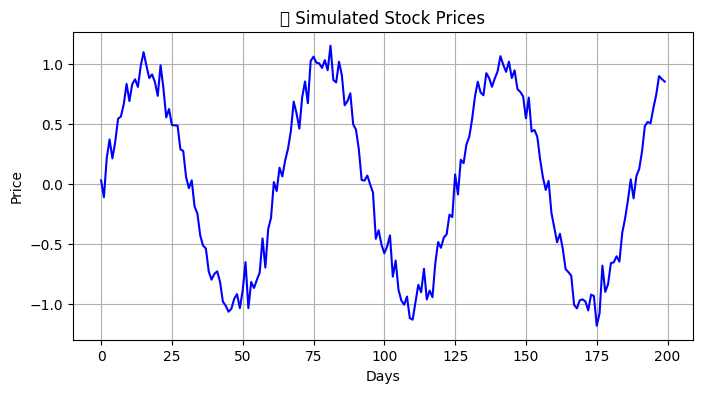


STEP 3 – NORMALIZING DATA (0 TO 1 RANGE)
Before Scaling (first 5): [ 0.02834077 -0.11144732  0.21553407  0.36969176  0.21233632]
After Scaling (first 5): [0.51888593 0.45903684 0.59903116 0.66503247 0.59766207]

STEP 4 – CREATING TRAINING SEQUENCES
Input shape (samples, timesteps, features): (190, 10, 1)
Target shape (samples, 1): (190, 1)

STEP 5 – BUILDING LSTM MODEL


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)


STEP 6 – TRAINING THE MODEL
Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1155
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0167
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0136
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0092
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0059
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0034
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0041
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0036
Epoch 9/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0037
Epoch 10/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0037
Epoch 11/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0035
Epoch 12/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0028
Epoch 13/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0030
Epoch 14/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0035
Epoch 15/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - los

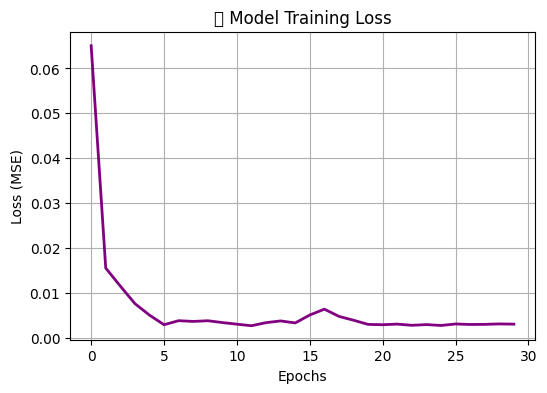


STEP 7 – MAKING PREDICTIONS
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predictions made: 190 samples

STEP 8 – VISUALIZING RESULTS


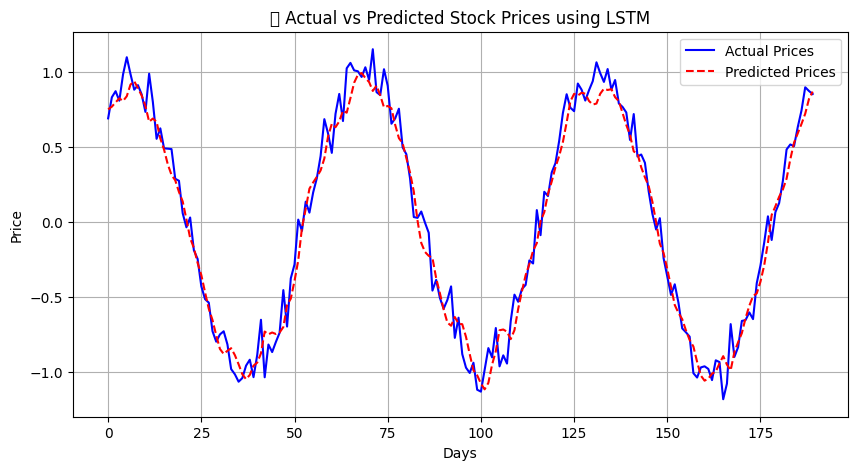


STEP 9 – EVALUATING MODEL PERFORMANCE
Mean Absolute Error (MAE): 0.1014
⚠️ Needs Improvement: Try more epochs or deeper LSTM.

STEP 10 – EXPERIMENTS FOR STUDENTS

🔹 Try changing sequence length (e.g., seq_length = 5 or 20)
🔹 Increase epochs to 50 or 100 for deeper training
🔹 Add another LSTM layer:

    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(seq_length, 1)),
        LSTM(32),
        Dense(1)
    ])

🔹 Use real stock data from Yahoo Finance:
    import yfinance as yf
    data = yf.download("AAPL", start="2022-01-01", end="2023-01-01")['Close']

🔹 Compare LSTM vs. RNN by replacing the LSTM layer with:
    from tensorflow.keras.layers import SimpleRNN
    model = Sequential([
        SimpleRNN(50, activation='tanh', input_shape=(seq_length, 1)),
        Dense(1)
    ])


SUMMARY

✅ We generated stock-like time-series data
✅ Normalized and structured it into sequences
✅ Built, trained, and evaluated an LSTM model
✅ Visualized how predictions follow actu

In [3]:
# ================================================
# 📘 WEEK 6 – DAY 3: RNNs & LSTMs for Time-Series Forecasting
# ================================================

# 🧩 GOAL:
# Build and train an LSTM model to predict future stock prices
# from past time-series data using Keras.

# ==============================================================
# 🧠 STEP 1: IMPORT LIBRARIES & HIDE WARNINGS
# ==============================================================

import warnings
warnings.filterwarnings('ignore')   # Hide all unnecessary warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error

# Pretty print section titles
def print_section(title):
    print("\n" + "="*70)
    print(title.upper())
    print("="*70)

# ==============================================================
# 📈 STEP 2: GENERATE OR LOAD STOCK PRICE DATA
# ==============================================================

print_section("STEP 2 – GENERATING STOCK PRICE DATA")

# Generate simple wave-like data (sine wave + noise)
days = np.arange(0, 200, 1)
prices = np.sin(days * 0.1) + np.random.normal(0, 0.1, len(days))

print(f"Total Days: {len(days)}")
print("Example Data:", prices[:5])

# Visualize generated data
plt.figure(figsize=(8,4))
plt.plot(days, prices, color='blue')
plt.title("📈 Simulated Stock Prices")
plt.xlabel("Days")
plt.ylabel("Price")
plt.grid(True)
plt.show()

# ==============================================================
# ⚙️ STEP 3: NORMALIZE DATA
# ==============================================================

print_section("STEP 3 – NORMALIZING DATA (0 TO 1 RANGE)")

scaler = MinMaxScaler(feature_range=(0, 1))
prices_scaled = scaler.fit_transform(prices.reshape(-1, 1))

print("Before Scaling (first 5):", prices[:5])
print("After Scaling (first 5):", prices_scaled[:5].flatten())

# ==============================================================
# 🔢 STEP 4: CREATE TRAINING SEQUENCES
# ==============================================================

print_section("STEP 4 – CREATING TRAINING SEQUENCES")

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 10
X, y = create_sequences(prices_scaled, seq_length)

print("Input shape (samples, timesteps, features):", X.shape)
print("Target shape (samples, 1):", y.shape)

# ==============================================================
# 🏗️ STEP 5: BUILD THE LSTM MODEL
# ==============================================================

print_section("STEP 5 – BUILDING LSTM MODEL")

model = Sequential([
    LSTM(50, activation='tanh', input_shape=(seq_length, 1)),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')
model.summary()

# ==============================================================
# 🏋️ STEP 6: TRAIN THE MODEL
# ==============================================================

print_section("STEP 6 – TRAINING THE MODEL")

history = model.fit(X, y, epochs=30, batch_size=16, verbose=1)

# Plot training loss
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], color='purple', linewidth=2)
plt.title("📉 Model Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.grid(True)
plt.show()

# ==============================================================
# 🔮 STEP 7: MAKE PREDICTIONS
# ==============================================================

print_section("STEP 7 – MAKING PREDICTIONS")

predictions = model.predict(X)

# Convert predictions back to original price scale
predicted_prices = scaler.inverse_transform(predictions)
actual_prices = scaler.inverse_transform(y)

print(f"Predictions made: {len(predicted_prices)} samples")

# ==============================================================
# 📊 STEP 8: VISUALIZE PREDICTED VS ACTUAL PRICES
# ==============================================================

print_section("STEP 8 – VISUALIZING RESULTS")

plt.figure(figsize=(10,5))
plt.plot(actual_prices, label='Actual Prices', color='blue')
plt.plot(predicted_prices, label='Predicted Prices', color='red', linestyle='dashed')
plt.title("📈 Actual vs Predicted Stock Prices using LSTM")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

# ==============================================================
# 🧮 STEP 9: EVALUATE MODEL PERFORMANCE
# ==============================================================

print_section("STEP 9 – EVALUATING MODEL PERFORMANCE")

mae = mean_absolute_error(actual_prices, predicted_prices)
print(f"Mean Absolute Error (MAE): {mae:.4f}")

# Interpretation Guide
if mae < 0.05:
    print("✅ Excellent Performance: Model fits data very well.")
elif mae < 0.10:
    print("👍 Good Performance: Predictions follow trend closely.")
else:
    print("⚠️ Needs Improvement: Try more epochs or deeper LSTM.")

# ==============================================================
# 🧠 STEP 10: EXPERIMENTS FOR STUDENTS
# ==============================================================

print_section("STEP 10 – EXPERIMENTS FOR STUDENTS")

print("""
🔹 Try changing sequence length (e.g., seq_length = 5 or 20)
🔹 Increase epochs to 50 or 100 for deeper training
🔹 Add another LSTM layer:

    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(seq_length, 1)),
        LSTM(32),
        Dense(1)
    ])

🔹 Use real stock data from Yahoo Finance:
    import yfinance as yf
    data = yf.download("AAPL", start="2022-01-01", end="2023-01-01")['Close']

🔹 Compare LSTM vs. RNN by replacing the LSTM layer with:
    from tensorflow.keras.layers import SimpleRNN
    model = Sequential([
        SimpleRNN(50, activation='tanh', input_shape=(seq_length, 1)),
        Dense(1)
    ])
""")

# ==============================================================
# ✅ END OF NOTEBOOK
# ==============================================================

print_section("SUMMARY")
print("""
✅ We generated stock-like time-series data
✅ Normalized and structured it into sequences
✅ Built, trained, and evaluated an LSTM model
✅ Visualized how predictions follow actual prices
✅ Learned to experiment with model parameters for better accuracy
""")




---



---




---

# 📘 **Week 6 – Advanced Deep Learning Concepts**


---



## 🧮 **Day 4 – Predictive Analytics & Time-Series Forecasting in Public Sector Applications**

---

## 🧠 **1. Introduction to Predictive Analytics**

### 🔹 What is Predictive Analytics?

**Predictive Analytics** is the science of using **historical data**, **statistical algorithms**, and **machine learning models** to predict **future outcomes or trends**.
It allows governments and organizations to **anticipate problems, allocate resources, and plan decisions proactively**.

💡 **In simple words:**

> Predictive analytics helps us *see the future* by learning from *the past.*

---

### 🔹 How It Works (Step-by-Step Flow)

| Step                                | Description                                              | Example                                           |
| ----------------------------------- | -------------------------------------------------------- | ------------------------------------------------- |
| 1️⃣ **Data Collection**             | Gather past records or sensor readings.                  | Collect traffic counts or hospital patient data.  |
| 2️⃣ **Data Cleaning & Preparation** | Handle missing values, remove noise.                     | Fix incomplete citizen data.                      |
| 3️⃣ **Feature Engineering**         | Identify important variables that affect the outcome.    | Add weather, holidays, time-of-day.               |
| 4️⃣ **Model Training**              | Train ML or deep learning models on historical patterns. | Use LSTM to forecast next week’s energy demand.   |
| 5️⃣ **Prediction & Visualization**  | Forecast future values and visualize them.               | Show predicted traffic congestion on a dashboard. |

---

### 🔹 Real-World Importance in Public Sector

Governments deal with **massive time-series data** — population, economy, health, energy, transportation.
Predictive analytics helps transform this data into actionable insights.

📊 **Applications include:**

* 📈 **Economic Planning:** Predict inflation or unemployment rates.
* 🚦 **Traffic Control:** Forecast rush-hour congestion using sensors.
* 🏥 **Healthcare:** Predict patient admissions and medicine demand.
* 💡 **Energy Management:** Estimate electricity load for next week.
* 🚔 **Crime Prevention:** Predict areas or times of higher crime risk.

---

### 🧩 **Why It Matters**

Predictive analytics helps public institutions move from:

> “Reacting after something happens” → to “Preventing before it happens.”

---

### 💬 **Mini Reflection Questions**

1. Why is predictive analytics important for government agencies?
2. Can predictions be wrong? What factors cause errors?
3. How could ethical concerns arise in public data prediction?

---

## 🏙️ **2. Public Sector Time-Series Examples**

Time-series forecasting plays a **central role** in making smarter, data-driven policies.
Let’s look at practical examples from various government departments.

---

### 🔹 Example 1: **Traffic Forecasting**

**Scenario:**
A city wants to predict hourly traffic volume to manage signals and avoid congestion.

**Data Sources:**

* Road sensors
* GPS data from vehicles
* Weather and event information

**Goal:**
Predict traffic volume for the next few hours.

**Usefulness:**

* Optimize signal timings
* Reduce travel delays and pollution
* Plan public transport schedules

---

### 🔹 Example 2: **Public Spending Forecasting**

**Scenario:**
A finance department wants to estimate future expenses on education, health, or infrastructure.

**Data Sources:**

* Monthly expenditure reports
* Project budgets and seasonal patterns

**Goal:**
Forecast next quarter’s spending to allocate funds wisely.

**Usefulness:**

* Prevent budget overruns
* Ensure timely fund distribution
* Identify departments that overspend

---

### 🔹 Example 3: **Crime Prediction**

**Scenario:**
A police department uses past records to predict potential hotspots.

**Data Sources:**

* Historical crime logs
* Time of day, area, event data

**Goal:**
Predict areas and times with a higher chance of crimes.

**Usefulness:**

* Deploy police more efficiently
* Improve citizen safety
* Identify long-term crime patterns

---

### 🔹 Example 4: **Health Forecasting**

**Scenario:**
Hospitals want to predict patient inflow or disease outbreaks.

**Data Sources:**

* Hospital admission data
* Temperature, humidity, and social event info

**Goal:**
Forecast patient numbers for coming weeks.

**Usefulness:**

* Allocate doctors and medicine efficiently
* Prepare for disease outbreaks early

---

### 🔹 Example 5: **Energy Demand Prediction**

**Scenario:**
An energy authority predicts electricity demand based on temperature, time, and usage.

**Goal:**
Estimate daily energy requirements for better grid management.

**Usefulness:**

* Avoid power outages
* Optimize production and storage
* Support green energy planning

---

### 🧩 **Open Datasets in the Public Sector**

Governments and global organizations release open data for researchers and students:

| Dataset Source                   | Description                                             | Link                                                                                 |
| -------------------------------- | ------------------------------------------------------- | ------------------------------------------------------------------------------------ |
| 🌍 **World Bank Open Data**      | Global development, economy, and environment indicators | [https://data.worldbank.org](https://data.worldbank.org)                             |
| 🏛️ **data.gov**                 | US Government’s open datasets                           | [https://www.data.gov](https://www.data.gov)                                         |
| 🇬🇧 **data.gov.uk**             | UK’s public sector datasets                             | [https://data.gov.uk](https://data.gov.uk)                                           |
| 🏥 **WHO Data Portal**           | Global health-related time-series                       | [https://www.who.int/data](https://www.who.int/data)                                 |
| 🚗 **UK Traffic Counts Dataset** | Traffic volumes by road segment                         | [https://roadtraffic.dft.gov.uk/downloads](https://roadtraffic.dft.gov.uk/downloads) |

---

### 💬 **Reflection Questions for Students**

1. Which public sector domain do you think benefits the most from predictive analytics?
2. How could time-series forecasting help your city or university?
3. What challenges might appear when using open government data?

---





---

## 🧮 **3. Data Preparation**

In this section, we’ll **simulate** a small public dataset (like monthly spending), clean it, scale it, and create **time windows** for forecasting future values.

---

### 🔹 Step 1: Collect or Simulate Public Data

We’ll create a dataset representing **monthly education spending** (in million USD) for 5 years (60 months).

```python
# ===============================================
# 📊 STEP 1: SIMULATE PUBLIC SECTOR DATA (SPENDING)
# ===============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

# Generate fake monthly spending data (in millions)
months = np.arange(0, 60)
spending = 500 + 50 * np.sin(months * 0.3) + np.random.normal(0, 10, len(months))

# Create a DataFrame
data = pd.DataFrame({"Month": months, "Spending": spending})

# Display first few rows
print("📘 Sample Data:")
print(data.head())

# Plot simulated spending trend
plt.figure(figsize=(8,4))
plt.plot(data["Month"], data["Spending"], color='teal', marker='o')
plt.title("📈 Monthly Education Spending (Simulated Data)")
plt.xlabel("Month")
plt.ylabel("Spending (Million USD)")
plt.grid(True)
plt.show()
```

💡 **Explanation:**

* We used a sine wave to create natural rise-and-fall patterns.
* Random noise adds realism (just like real-world fluctuations).

---

### 🔹 Step 2: Clean and Scale Data

Before feeding data to a neural network, we normalize it between 0 and 1.

```python
# ===============================================
# 🧹 STEP 2: CLEAN AND SCALE DATA
# ===============================================

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_spending = scaler.fit_transform(data["Spending"].values.reshape(-1, 1))

print("Before Scaling (first 5):", data["Spending"].values[:5])
print("After Scaling (first 5):", scaled_spending[:5].flatten())
```

---

### 🔹 Step 3: Create Time Windows

We’ll use previous `12` months to predict the **next month’s spending** — this forms the model’s “memory window”.

```python
# ===============================================
# 🔢 STEP 3: CREATE TIME WINDOWS
# ===============================================

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

seq_length = 12  # last 12 months → next month's spending
X, y = create_sequences(scaled_spending, seq_length)

print("Input shape:", X.shape)
print("Target shape:", y.shape)
```

---

## 🧩 **4. Building a Simple Time-Series Forecasting Model**

We’ll use a small **LSTM model** for forecasting, though students can also try an **MLP** for comparison.

---

### 🔹 Step 1: Define the LSTM Model

```python
# ===============================================
# 🧠 STEP 4: BUILDING THE LSTM MODEL
# ===============================================

model = Sequential([
    LSTM(32, activation='tanh', input_shape=(seq_length, 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()
```

💡 **Explanation:**

* **LSTM(32)** → 32 memory units for learning temporal patterns.
* **Dense(1)** → Predicts the next month’s spending.
* **Loss = MSE** → Measures average squared difference between predictions and actual values.

---

### 🔹 Step 2: Define Features and Targets

The model’s **input** is a 12-month window (past values),
and **target** is the spending of the next month.

✅ *Each input sample looks like:*
`[month₁, month₂, ..., month₁₂] → month₁₃`

---

## 🧮 **5. Training and Validation**

Now we’ll train the model on the first 48 months and test it on the remaining 12 (unseen data).

```python
# ===============================================
# 🏋️ STEP 5: TRAINING AND VALIDATION
# ===============================================

# Split into train and test sets (80% train, 20% test)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=8, verbose=0)

# Plot training loss
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], color='purple')
plt.title("📉 Training Loss (MSE over Epochs)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Make predictions
y_pred = model.predict(X_test)

# Inverse scale predictions and actuals
y_pred_rescaled = scaler.inverse_transform(y_pred)
y_test_rescaled = scaler.inverse_transform(y_test)

# Evaluate results
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
mse = mean_squared_error(y_test_rescaled, y_pred_rescaled)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
```

💡 **Interpretation:**

* **MAE** shows average absolute error in million USD.
* **MSE** shows overall variance in prediction errors.

Lower values = better performance ✅

---

## 📊 **6. Visualization and Interpretation**

Finally, we’ll compare **predicted vs. real** government spending and interpret the insights.

---

```python
# ===============================================
# 📊 STEP 6: VISUALIZATION & INTERPRETATION
# ===============================================

plt.figure(figsize=(10,5))
plt.plot(y_test_rescaled, label="Actual Spending", color="blue", marker="o")
plt.plot(y_pred_rescaled, label="Predicted Spending", color="red", linestyle="dashed", marker="x")
plt.title("📈 Actual vs Predicted Public Spending (LSTM Forecast)")
plt.xlabel("Time Steps (Months)")
plt.ylabel("Spending (Million USD)")
plt.legend()
plt.grid(True)
plt.show()
```

---

### 💡 **Interpretation for Policymakers**

📊 Suppose this model was used by a **Ministry of Education**:

* The **blue line** = actual recorded spending.
* The **red dashed line** = model’s prediction for the next month.

**Insights:**

* If predicted spending rises — government can allocate funds early.
* If forecast shows drops — indicates reduced upcoming expenditure or project slowdowns.
* Long-term upward trend = signals future budget increase needed.
* Forecasting helps **stabilize budgets** and **avoid overspending**.

---

### 🧩 **Reflection Questions for Students**

1. Why is data scaling important before training models?
2. What happens if we choose a very short or very long sequence length?
3. How could such forecasting help in public health or energy management?
4. What additional features (e.g., holidays, temperature, policy changes) might improve predictions?

---



STEP 2 – GENERATING SIMULATED PUBLIC SECTOR DATA
📘 Sample Data:
   Month    Spending
0      0  506.691173
1      1  534.574506
2      2  544.401557
3      3  554.957457
4      4  528.230350


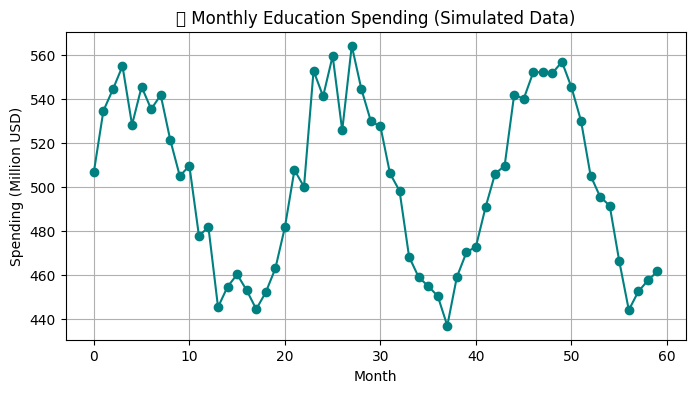


STEP 3 – CLEANING AND SCALING DATA
Before Scaling (first 5): [506.69117341 534.57450573 544.40155701 554.957457   528.23034986]
After Scaling (first 5): [0.54840628 0.76736002 0.8445269  0.92741706 0.71754257]

STEP 4 – CREATING TIME WINDOWS FOR FORECASTING
Input shape (samples, timesteps, features): (48, 12, 1)
Target shape (samples, 1): (48, 1)

STEP 5 – BUILDING THE LSTM MODEL


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)


STEP 6 – TRAINING AND VALIDATION


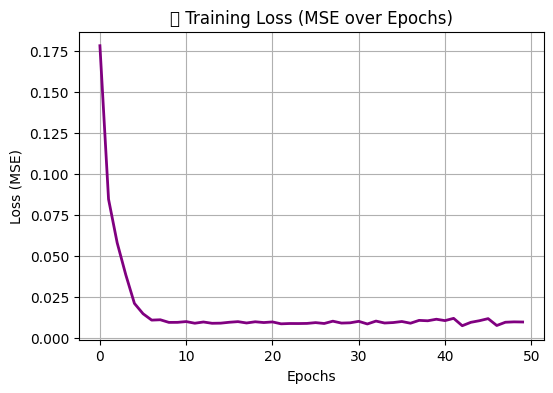


STEP 7 – MAKING PREDICTIONS


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
Predictions made: 10 samples

STEP 8 – VISUALIZING ACTUAL VS PREDICTED SPENDING


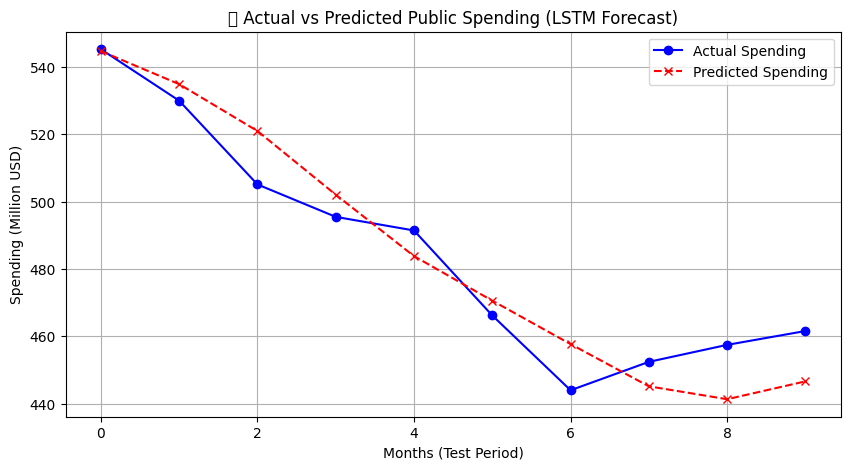


STEP 9 – MODEL PERFORMANCE METRICS
Mean Absolute Error (MAE): 9.20 Million USD
Mean Squared Error (MSE): 112.10 (Million USD)^2
👍 Good: Predictions follow the trend closely with small errors.

STEP 10 – POLICY INSIGHTS

📊 Interpretation for Policymakers:
-----------------------------------
• The blue line shows actual recorded spending.
• The red dashed line shows the model’s predicted spending.

If predicted spending rises ➜ Allocate funds early to avoid shortfalls.
If forecast shows decline ➜ Indicates upcoming project completion or reduced activity.
If spending fluctuates strongly ➜ Suggests volatility; plan contingency budgets.

These insights help ministries stabilize budgets, improve transparency,
and ensure resources are distributed efficiently.


STEP 11 – STUDENT EXPERIMENTS

🔹 Change seq_length (e.g., 6 or 24 months) and observe accuracy.
🔹 Increase epochs to 100 for deeper learning.
🔹 Add an extra LSTM layer:
    model = Sequential([
        LSTM(64, return_sequences=True, 

In [4]:
# ===============================================================
# 📘 WEEK 6 – DAY 4: PREDICTIVE ANALYTICS & TIME-SERIES FORECASTING
# ===============================================================
# 🧩 GOAL:
# Simulate public-sector time-series data (e.g., government spending)
# and build an LSTM model to forecast future values.
# ===============================================================

# 🧠 STEP 1: IMPORT LIBRARIES & HIDE WARNINGS
# ---------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Helper function to print section titles neatly
def print_section(title):
    print("\n" + "="*70)
    print(title.upper())
    print("="*70)

# ===============================================================
# 📊 STEP 2: SIMULATE PUBLIC-SECTOR DATA (E.G., GOVERNMENT SPENDING)
# ===============================================================

print_section("STEP 2 – GENERATING SIMULATED PUBLIC SECTOR DATA")

# Generate fake monthly education spending data (in million USD)
months = np.arange(0, 60)  # 5 years of monthly data
spending = 500 + 50 * np.sin(months * 0.3) + np.random.normal(0, 10, len(months))

# Create a DataFrame
data = pd.DataFrame({"Month": months, "Spending": spending})
print("📘 Sample Data:")
print(data.head())

# Visualize the data trend
plt.figure(figsize=(8,4))
plt.plot(data["Month"], data["Spending"], color='teal', marker='o')
plt.title("📈 Monthly Education Spending (Simulated Data)")
plt.xlabel("Month")
plt.ylabel("Spending (Million USD)")
plt.grid(True)
plt.show()

# ===============================================================
# 🧹 STEP 3: CLEAN AND SCALE DATA
# ===============================================================

print_section("STEP 3 – CLEANING AND SCALING DATA")

# Normalize spending between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_spending = scaler.fit_transform(data["Spending"].values.reshape(-1, 1))

print("Before Scaling (first 5):", data["Spending"].values[:5])
print("After Scaling (first 5):", scaled_spending[:5].flatten())

# ===============================================================
# 🔢 STEP 4: CREATE TIME WINDOWS (SEQUENCES)
# ===============================================================

print_section("STEP 4 – CREATING TIME WINDOWS FOR FORECASTING")

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])   # past seq_length values
        y.append(data[i + seq_length])     # next value to predict
    return np.array(X), np.array(y)

seq_length = 12  # use past 12 months to predict next month
X, y = create_sequences(scaled_spending, seq_length)

print("Input shape (samples, timesteps, features):", X.shape)
print("Target shape (samples, 1):", y.shape)

# ===============================================================
# 🧠 STEP 5: BUILD THE LSTM MODEL
# ===============================================================

print_section("STEP 5 – BUILDING THE LSTM MODEL")

model = Sequential([
    LSTM(32, activation='tanh', input_shape=(seq_length, 1)),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')
model.summary()

# ===============================================================
# 🏋️ STEP 6: TRAIN AND VALIDATE THE MODEL
# ===============================================================

print_section("STEP 6 – TRAINING AND VALIDATION")

# Split into 80% training and 20% testing
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Train the LSTM model
history = model.fit(X_train, y_train, epochs=50, batch_size=8, verbose=0)

# Plot training loss
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], color='purple', linewidth=2)
plt.title("📉 Training Loss (MSE over Epochs)")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.grid(True)
plt.show()

# ===============================================================
# 🔮 STEP 7: MAKE PREDICTIONS ON TEST DATA
# ===============================================================

print_section("STEP 7 – MAKING PREDICTIONS")

y_pred = model.predict(X_test)

# Inverse transform to get values back in Million USD
y_pred_rescaled = scaler.inverse_transform(y_pred)
y_test_rescaled = scaler.inverse_transform(y_test)

print(f"Predictions made: {len(y_pred_rescaled)} samples")

# ===============================================================
# 📊 STEP 8: VISUALIZE RESULTS
# ===============================================================

print_section("STEP 8 – VISUALIZING ACTUAL VS PREDICTED SPENDING")

plt.figure(figsize=(10,5))
plt.plot(y_test_rescaled, label="Actual Spending", color="blue", marker='o')
plt.plot(y_pred_rescaled, label="Predicted Spending", color="red", linestyle="dashed", marker='x')
plt.title("📈 Actual vs Predicted Public Spending (LSTM Forecast)")
plt.xlabel("Months (Test Period)")
plt.ylabel("Spending (Million USD)")
plt.legend()
plt.grid(True)
plt.show()

# ===============================================================
# 🧮 STEP 9: EVALUATE MODEL PERFORMANCE
# ===============================================================

print_section("STEP 9 – MODEL PERFORMANCE METRICS")

mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
mse = mean_squared_error(y_test_rescaled, y_pred_rescaled)

print(f"Mean Absolute Error (MAE): {mae:.2f} Million USD")
print(f"Mean Squared Error (MSE): {mse:.2f} (Million USD)^2")

# Interpretation
if mae < 5:
    print("✅ Excellent: Model predictions are very close to actual spending.")
elif mae < 10:
    print("👍 Good: Predictions follow the trend closely with small errors.")
else:
    print("⚠️ Needs Improvement: Try longer training or more layers.")

# ===============================================================
# 🧭 STEP 10: POLICY INSIGHTS & INTERPRETATION
# ===============================================================

print_section("STEP 10 – POLICY INSIGHTS")

print("""
📊 Interpretation for Policymakers:
-----------------------------------
• The blue line shows actual recorded spending.
• The red dashed line shows the model’s predicted spending.

If predicted spending rises ➜ Allocate funds early to avoid shortfalls.
If forecast shows decline ➜ Indicates upcoming project completion or reduced activity.
If spending fluctuates strongly ➜ Suggests volatility; plan contingency budgets.

These insights help ministries stabilize budgets, improve transparency,
and ensure resources are distributed efficiently.
""")

# ===============================================================
# 🎯 STEP 11: STUDENT EXPERIMENTS
# ===============================================================

print_section("STEP 11 – STUDENT EXPERIMENTS")

print("""
🔹 Change seq_length (e.g., 6 or 24 months) and observe accuracy.
🔹 Increase epochs to 100 for deeper learning.
🔹 Add an extra LSTM layer:
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(seq_length, 1)),
        LSTM(32),
        Dense(1)
    ])
🔹 Try a different optimizer (SGD, RMSprop).
🔹 Replace LSTM with a Dense (MLP) model and compare results.
🔹 Use real open data (from data.gov or World Bank) for public forecasting.
""")

# ===============================================================
# ✅ END OF NOTEBOOK
# ===============================================================

print_section("SUMMARY")
print("""
✅ We simulated a public-sector dataset (monthly spending)
✅ Cleaned, scaled, and created time-series sequences
✅ Built and trained an LSTM forecasting model
✅ Visualized predictions vs. actual values
✅ Interpreted how forecasts can assist government decision-making
""")
